# 02_eda

_This notebook will be filled in during its corresponding project phase._

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/Customer-Churn-Records.csv")

# Folder where every chart gets saved as a PNG, for the final EDA report later
FIGURES_DIR = "../reports/figures"

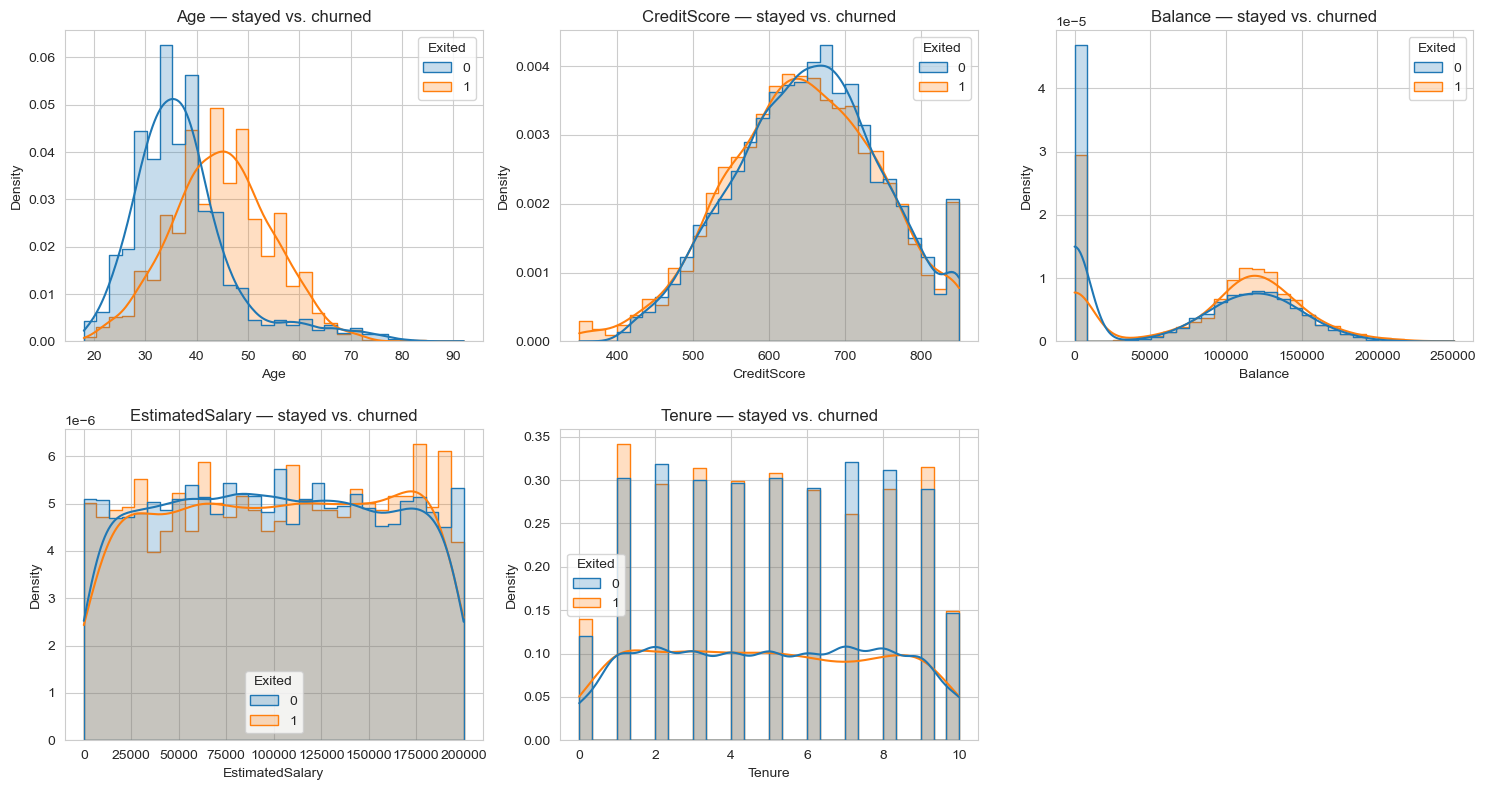

In [9]:
import os

numeric_cols = ["Age", "CreditScore", "Balance", "EstimatedSalary", "Tenure"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue="Exited", bins=30, kde=True, ax=axes[i],
                 element="step", stat="density", common_norm=False)
    axes[i].set_title(f"{col} — stayed vs. churned")

axes[-1].axis("off")  # unused subplot slot
plt.tight_layout()
os.makedirs(FIGURES_DIR, exist_ok=True)
plt.savefig(f"{FIGURES_DIR}/numeric_distributions.png", dpi=120)
plt.show()

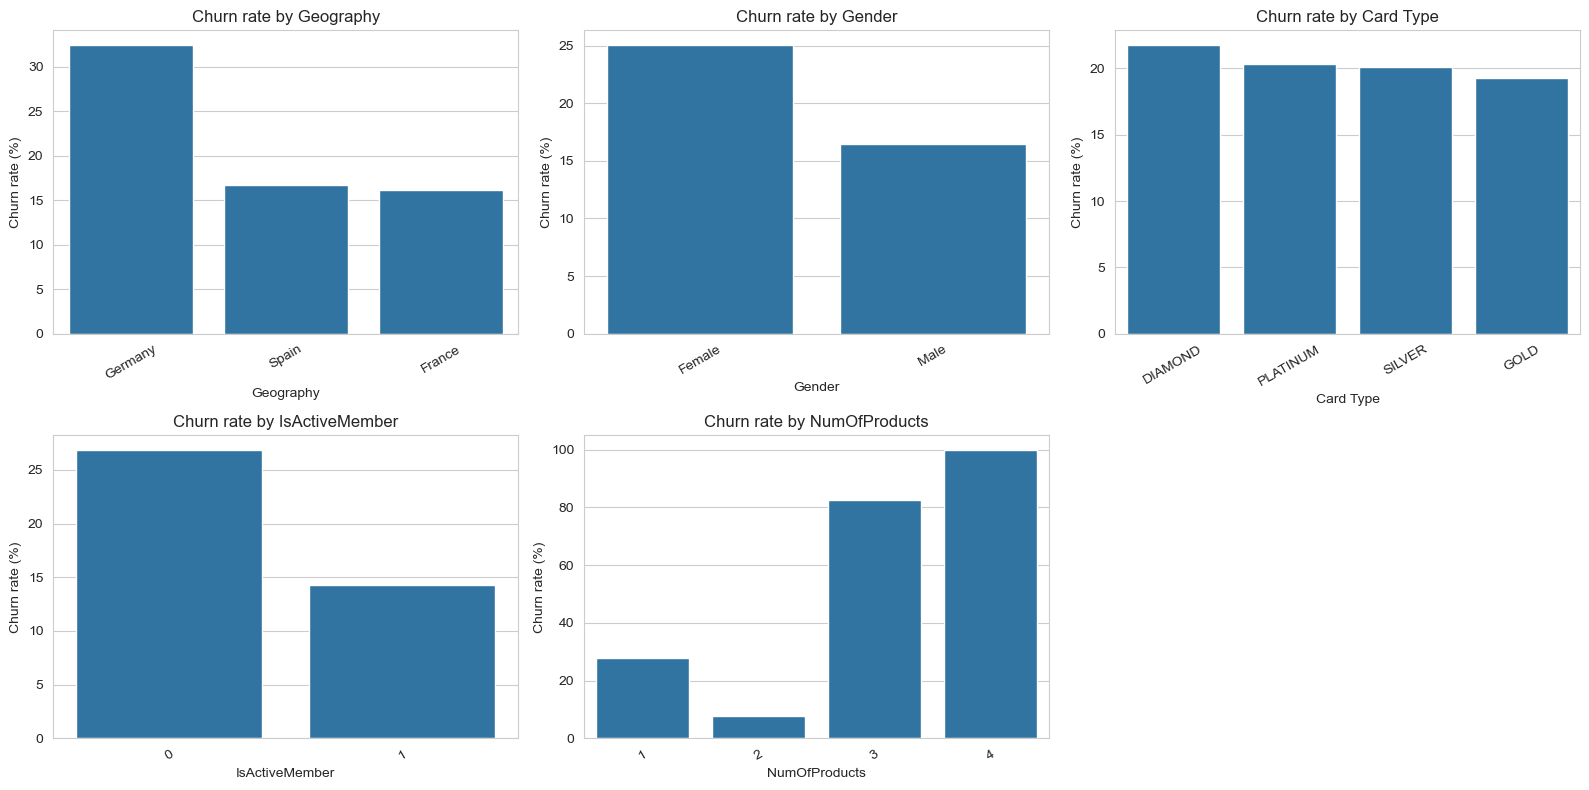

In [10]:
categorical_cols = ["Geography", "Gender", "Card Type", "IsActiveMember", "NumOfProducts"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)["Exited"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[i])
    axes[i].set_ylabel("Churn rate (%)")
    axes[i].set_title(f"Churn rate by {col}")
    axes[i].tick_params(axis="x", rotation=30)

axes[-1].axis("off")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/categorical_churn_rates.png", dpi=120)
plt.show()

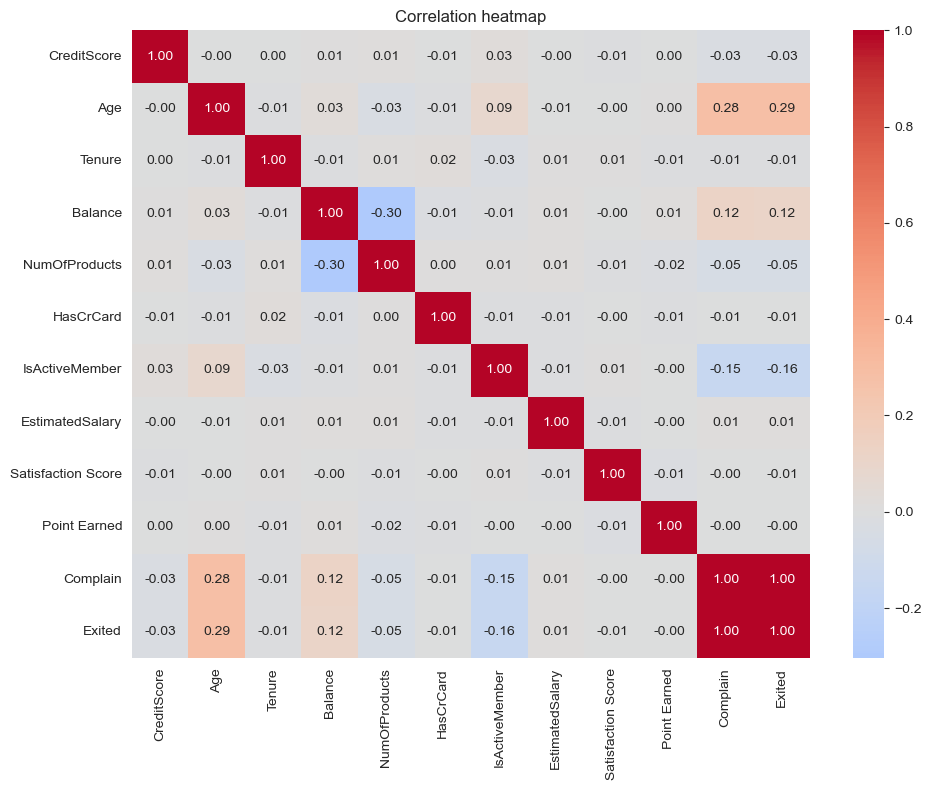

In [11]:
corr_cols = [
    "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard",
    "IsActiveMember", "EstimatedSalary", "Satisfaction Score", "Point Earned",
    "Complain", "Exited",
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/correlation_heatmap.png", dpi=120)
plt.show()

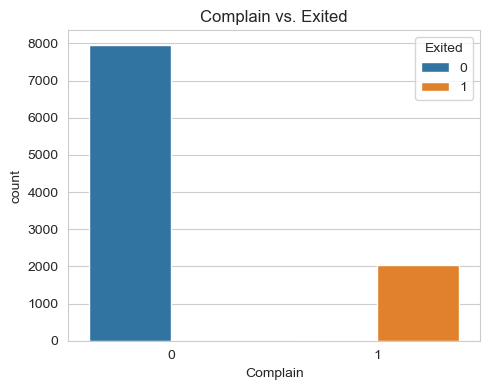

Exited            0          1
Complain                      
0         99.949723   0.050277
1          0.489237  99.510763


In [12]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Complain", hue="Exited")
plt.title("Complain vs. Exited")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/complain_vs_exited.png", dpi=120)
plt.show()

print(pd.crosstab(df["Complain"], df["Exited"], normalize="index") * 100)